In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
customers_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\olist_customers_dataset.csv")
orders_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\olist_orders_dataset.csv")
products_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\olist_products_dataset.csv")
sellers_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\olist_sellers_dataset.csv")
order_payments_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\olist_order_payments_dataset.csv")
order_reviews_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\olist_order_reviews_dataset.csv")
order_items_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\olist_order_items_dataset.csv")
product_category_transalation_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\product_category_name_translation.csv")
geolocation_df = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\raw_datasets\olist_geolocation_dataset.csv")

### Missing value columns

In [7]:
datasets = {
    'customers_df': customers_df,
    'orders_df': orders_df,
    'products_df': products_df,
    'sellers_df': sellers_df,
    'order_payments_df': order_payments_df,
    'order_reviews_df': order_reviews_df,
    'order_items_df': order_items_df,
    'product_category_transalation_df': product_category_transalation_df,
    'geolocation_df': geolocation_df
}

null_summary_data = []

for dataset_name, df in datasets.items():
    total_rows = len(df)
    null_counts = df.isnull().sum()
    columns_with_nulls = null_counts[null_counts > 0]
    
    for col_name, null_count in columns_with_nulls.items():
        missing_percentage = (null_count / total_rows) * 100
        null_summary_data.append({
            'Dataset Name': dataset_name,
            'Column Name': col_name,
            'Total Rows': total_rows,
            'Missing Values Count': null_count,
            'Missing Percentage (%)': round(missing_percentage, 2)
        })

null_summary_df = pd.DataFrame(null_summary_data).sort_values(by='Missing Percentage (%)',ascending=False).reset_index()
null_summary_df

,index,Dataset Name,Column Name,Total Rows,Missing Values Count,Missing Percentage (%)
0,11,order_reviews_df,review_comment_title,99224,87656,88.34
1,12,order_reviews_df,review_comment_message,99224,58247,58.70
2,2,orders_df,order_delivered_customer_date,99441,2965,2.98
3,4,products_df,product_name_lenght,32951,610,1.85
4,3,products_df,product_category_name,32951,610,1.85
5,5,products_df,product_description_lenght,32951,610,1.85
6,6,products_df,product_photos_qty,32951,610,1.85
7,1,orders_df,order_delivered_carrier_date,99441,1783,1.79
8,0,orders_df,order_approved_at,99441,160,0.16
9,8,products_df,product_length_cm,32951,2,0.01


### Duplicates

In [15]:
duplicate_summary_data = []

for dataset_name, df in datasets.items():
    duplicates = df.duplicated().sum()
    duplicate_rows = duplicates[duplicates >= 0]
    
    for i in duplicate_rows:
        duplicate_summary_data.append({
            'Dataset Name': dataset_name,
            'Number of Duplicate Rows': duplicates,
            'Total Rows': len(df)
        })

duplicate_summary_df = pd.DataFrame(duplicate_summary_data).sort_values(by='Dataset Name').reset_index(drop=True)
duplicate_summary_df

,Dataset Name,Number of Duplicate Rows,Total Rows
0,customers_df,0,99441
1,geolocation_df,261836,1000163
2,order_items_df,0,112650
3,order_payments_df,0,103886
4,order_reviews_df,0,99224
5,orders_df,0,99441
6,product_category_transalation_df,0,71
7,products_df,0,32951
8,sellers_df,0,3095


In [18]:
geolocation_df[geolocation_df.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


### Checking for incorrect datatypes & inconsistent/invalid values:

In [22]:
for name, df in datasets.items():
    print(f'Overview of {name} :')
    display(df.info())
    print('\n')

Overview of customers_df :
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


None



Overview of orders_df :
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


None



Overview of products_df :
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


...

None



Overview of product_category_transalation_df :
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB


None



Overview of geolocation_df :
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 50.1 MB


None

In [23]:
for name, df in datasets.items():
    print(f'Statistical summary of {name} :')
    display(df.describe(include='all'))
    print('\n')

Statistical summary of customers_df :


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN




Statistical summary of orders_df :


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522




Statistical summary of products_df :


...

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000




Statistical summary of product_category_transalation_df :


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1




Statistical summary of geolocation_df :


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


### Identifying potential outliers

In [9]:
outlier_summary_data = []
for dataset_name, df in datasets.items():
    total_rows = len(df)
    numerical_cols = df.select_dtypes(include=['int64','float64']).columns
    for col_name in numerical_cols:
        col_data = df[col_name].dropna()
        if(len(col_data)) == 0:
            continue
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3-Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outlier_count = ((col_data<lower_bound) | (col_data>upper_bound)).sum()

        if outlier_count > 0:
            outlier_percentage = (outlier_count/total_rows)*100
            outlier_summary_data.append({
                'Dataset name': dataset_name,
                'Column name': col_name,
                'Total rows': total_rows,
                'Outlier count': outlier_count,
                'Outlier percentage': round(outlier_percentage,2)
            })

outlier_summary_df = pd.DataFrame(outlier_summary_data)
outlier_summary_df

,Dataset name,Column name,Total rows,Outlier count,Outlier percentage
0,products_df,product_name_lenght,32951,290,0.88
1,products_df,product_description_lenght,32951,2078,6.31
2,products_df,product_photos_qty,32951,849,2.58
3,products_df,product_weight_g,32951,4551,13.81
4,products_df,product_length_cm,32951,1380,4.19
5,products_df,product_height_cm,32951,1892,5.74
6,products_df,product_width_cm,32951,912,2.77
7,order_payments_df,payment_sequential,103886,4526,4.36
8,order_payments_df,payment_installments,103886,6313,6.08
9,order_payments_df,payment_value,103886,7981,7.68


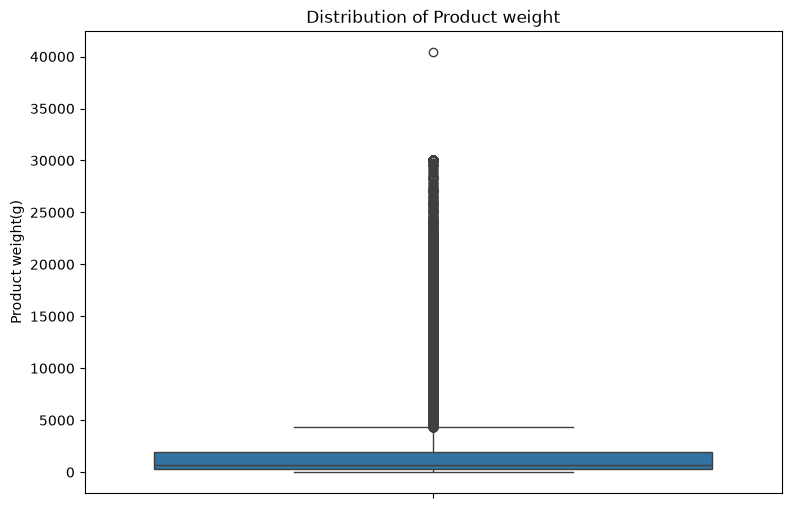

In [15]:
plt.figure(figsize=(9,6))
sns.boxplot(y=datasets['products_df']['product_weight_g'])
plt.title('Distribution of Product weight')
plt.ylabel('Product weight(g)')
plt.show()

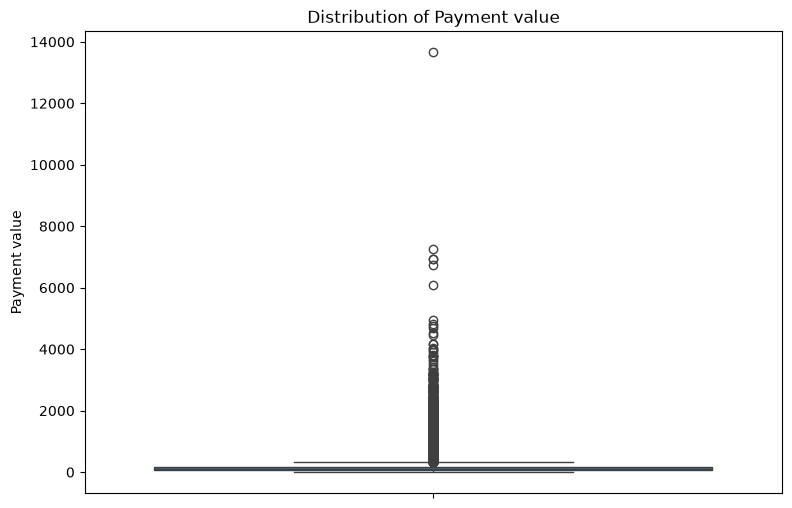

In [18]:
plt.figure(figsize=(9,6))
sns.boxplot(y=datasets['order_payments_df']['payment_value'])
plt.title('Distribution of Payment value')
plt.ylabel('Payment value')
plt.show()

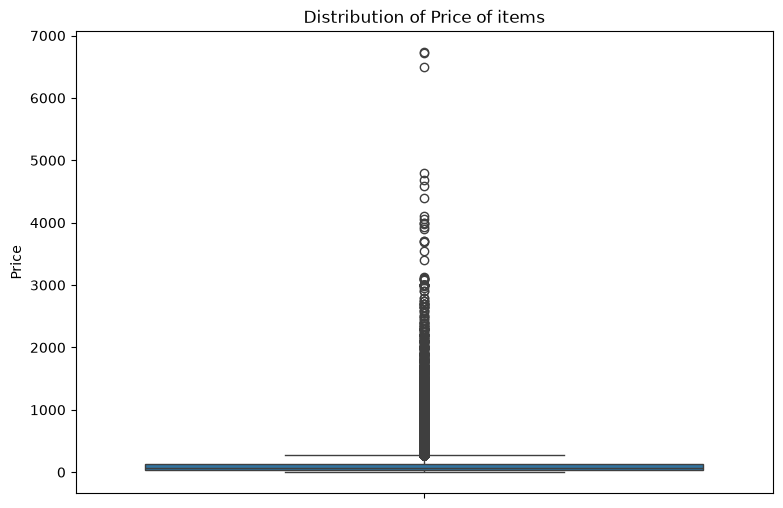

In [19]:
plt.figure(figsize=(9,6))
sns.boxplot(y=datasets['order_items_df']['price'])
plt.title('Distribution of Price of items')
plt.ylabel('Price')
plt.show()

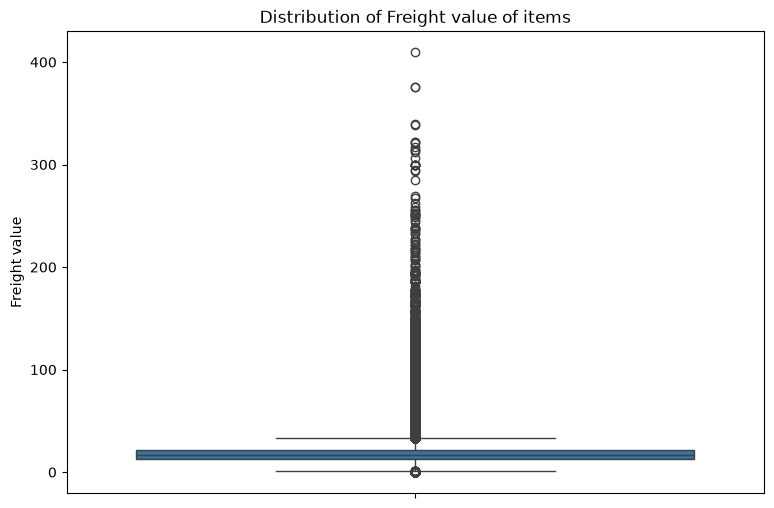

In [20]:
plt.figure(figsize=(9,6))
sns.boxplot(y=datasets['order_items_df']['freight_value'])
plt.title('Distribution of Freight value of items')
plt.ylabel('Freight value')
plt.show()

### Primary key Uniqueness
   The describe function itself shows the primary key uniqueness in tables customers_df, orders_df, products_df, sellers_df, product_category_translation_df.

In [21]:
order_payments_df['payment_sequential'].astype('str').describe()

count     103886
unique        29
top            1
freq       99360
Name: payment_sequential, dtype: object

In [22]:
order_reviews_df['review_id'].astype('str').describe()

count                                99224
unique                               98410
top       c444278834184f72b1484dfe47de7f97
freq                                     3
Name: review_id, dtype: object

In [24]:
order_items_df['order_item_id'].astype('str').describe()

count     112650
unique        21
top            1
freq       98666
Name: order_item_id, dtype: object

In [25]:
geolocation_df['geolocation_zip_code_prefix'].astype('str').describe()

count     1000163
unique      19015
top         24220
freq         1146
Name: geolocation_zip_code_prefix, dtype: object

In [27]:
order_payments_df.groupby(['order_id','payment_sequential']).size().max()==1

np.True_

In [26]:
order_items_df.groupby(['order_id','order_item_id']).size().max()==1

np.True_

In [29]:
order_reviews_df.groupby(['order_id','review_id']).size().max()==1

np.True_

In [28]:
duplicate_reviews = order_reviews_df[order_reviews_df.duplicated(subset=['review_id'],keep=False)]
duplicate_reviews.sort_values(by='review_id')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
...,...,...,...,...,...,...,...
40378,fe5c833752953fed3209646f1f63b53c,d3775e436e60258e62e678a0f68a0f8d,1,NaN,"Comprei dois produtos e ambos, mesmo enviados ...",2018-02-28 00:00:00,2018-02-28 13:57:52
7870,ff2fc9e68f8aabfbe18d710b83aabd30,2da58e0a7dcfa4ce1e00fad9d03ca3b5,2,NaN,NaN,2018-03-17 00:00:00,2018-03-19 11:44:15
82521,ff2fc9e68f8aabfbe18d710b83aabd30,1078d496cc6ab9a8e6f2be77abf5091b,2,NaN,NaN,2018-03-17 00:00:00,2018-03-19 11:44:15
1985,ffb8cff872a625632ac983eb1f88843c,c88b1d1b157a9999ce368f218a407141,3,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:41:07
